# Alignment and analysis of single-cell RNA-seq data

Turning raw 10x Genomics sequencing reads into a gene-by-cell count matrix is
the first step of every scRNA-seq study. This tutorial walks through that
**preprocessing** stage end-to-end on the
[pbmc_1k v3 dataset](https://support.10xgenomics.com/single-cell-gene-expression/datasets/3.0.0/pbmc_1k_v3)
from 10x Genomics, and then runs a basic downstream analysis with the
OmicVerse pipeline.

## The simpleaf / salmon / alevin-fry pipeline (primary path)

OmicVerse drives raw-read quantification through **simpleaf**, the one-stop
command-line front end for the [COMBINE-lab](https://github.com/COMBINE-lab)
single-cell ecosystem. simpleaf orchestrates two tools:

* **salmon** (or **piscem**) performs *selective alignment* / mapping of the
  reads against an index, and
* **alevin-fry** turns those mappings into a UMI-deduplicated count matrix.

Why a mapping-based quantifier? Selective alignment against a
**splici** (spliced + intron) reference resolves reads that originate from
nascent (intronic) transcripts, gives accurate gene-level counts, USA-mode
spliced/unspliced/ambiguous layers for RNA-velocity, and runs with a small,
roughly constant memory footprint. simpleaf wraps the whole chain
(index build, mapping, permit-list generation, collation, quantification)
behind two commands.

OmicVerse exposes this as `ov.alignment.simpleaf`:

* `ov.alignment.simpleaf.index(...)` -> `simpleaf index` (build splici reference + index)
* `ov.alignment.simpleaf.count(...)` -> `simpleaf quant` (map + quantify -> AnnData `.h5ad`)
* `ov.alignment.simpleaf.pipeline(...)` -> one-click index + quant

The kallisto / bustools / **kb-python** workflow remains available as an
alternative backend through `ov.alignment.single` (see the last section).

If you find this tutorial helpful, please cite simpleaf, alevin-fry and OmicVerse:

* He, D., Soneson, C. & Patro, R. Understanding and evaluating ambiguous RNA-seq
  quantification with simpleaf and alevin-fry. *Bioinformatics* (2023).
  https://doi.org/10.1093/bioinformatics/btad614
* He, D., Zakeri, M., Sarkar, H. et al. Alevin-fry unlocks rapid, accurate and
  memory-frugal quantification of single-cell RNA-seq data. *Nature Methods* 19,
  316-322 (2022). https://doi.org/10.1038/s41592-022-01408-3

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd
import numpy as np
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Working directory and tool location

simpleaf, salmon and alevin-fry are bioconda packages. Install them once into a
dedicated conda environment:

```bash
mamba create -n simpleaf -c conda-forge -c bioconda simpleaf salmon alevin-fry piscem
```

The OmicVerse wrappers accept a `simpleaf_bin` argument that points at that
environment's `bin/` directory, so you do not have to activate the environment.
We also keep all reference / FASTQ / output files under a scratch directory with
plenty of free disk (the genome FASTA, the index and the FASTQs together need
~15 GB).

In [2]:
import os

# Directory holding the simpleaf/salmon/alevin-fry binaries.
simpleaf_bin = "/scratch/users/steorra/envs/simpleaf/bin"

# Scratch working directory (NOT the OmicVerse repo).
work_dir = "/scratch/users/steorra/simpleaf_tutorial"
os.chdir(work_dir)
os.makedirs("pbmc_1k_v3", exist_ok=True)
print("Working directory:", os.getcwd())

Working directory: /scratch/users/steorra/simpleaf_tutorial


## Download the reference genome and the sequencing reads

We need three inputs:

1. a **genome FASTA** and **GTF annotation** to build the splici reference
   (Ensembl GRCh38, release 108), and
2. the **pbmc_1k v3 FASTQ** reads from 10x Genomics.

The genome FASTA is ~840 MB and the FASTQ archive is ~5 GB, so this download
takes a while. `wget -c` resumes interrupted transfers, so re-running the cell
is safe.

In [3]:
# Human genome FASTA + GTF annotation (Ensembl GRCh38, release 108).
!wget -q -c https://ftp.ensembl.org/pub/release-108/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz -O pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz
!wget -q -c https://ftp.ensembl.org/pub/release-108/gtf/homo_sapiens/Homo_sapiens.GRCh38.108.gtf.gz -O pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz
print("genome + GTF downloaded")
!ls -lh pbmc_1k_v3/Homo_sapiens.GRCh38.*

genome + GTF downloaded


-rw-r--r-- 1 steorra xiaojie  52M Oct  4  2022 pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz
-rw-r--r-- 1 steorra xiaojie 841M Oct  4  2022 pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz


In [4]:
# pbmc_1k v3 FASTQ reads (~5 GB tar archive from 10x Genomics).
!wget -q -c https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_fastqs.tar -O pbmc_1k_v3/pbmc_1k_v3_fastqs.tar
!tar -xf pbmc_1k_v3/pbmc_1k_v3_fastqs.tar -C pbmc_1k_v3
!ls -lh pbmc_1k_v3/pbmc_1k_v3_fastqs/

total 5.0G
-rw-r--r-- 1 steorra xiaojie 245M Nov  2  2018 pbmc_1k_v3_S1_L001_I1_001.fastq.gz
-rw-r--r-- 1 steorra xiaojie 719M Nov  2  2018 pbmc_1k_v3_S1_L001_R1_001.fastq.gz
-rw-r--r-- 1 steorra xiaojie 1.7G Nov  2  2018 pbmc_1k_v3_S1_L001_R2_001.fastq.gz
-rw-r--r-- 1 steorra xiaojie 243M Nov  2  2018 pbmc_1k_v3_S1_L002_I1_001.fastq.gz
-rw-r--r-- 1 steorra xiaojie 714M Nov  2  2018 pbmc_1k_v3_S1_L002_R1_001.fastq.gz
-rw-r--r-- 1 steorra xiaojie 1.7G Nov  2  2018 pbmc_1k_v3_S1_L002_R2_001.fastq.gz


## Build the splici reference and index

`ov.alignment.simpleaf.index` runs `simpleaf index`, which (a) extracts a
**spliced + intronic ("splici")** transcriptome from the genome FASTA + GTF and
(b) builds a mapping index from it, together with a 3-column transcript-to-gene
(`t2g`) map carrying the USA (spliced / unspliced / ambiguous) status of each
sequence.

Key arguments:

* `rlen=91` - the biological read-2 length for 10x v3 chemistry; it sets the
  intronic flank length added around each exon.
* `use_piscem=True` - build a **piscem** index instead of the default salmon
  index. piscem is faster and uses less memory.
* `threads` - 8-16 worker threads speeds the build up considerably.

This step is the most resource-intensive part of the tutorial (it reads the
whole genome); on a multi-core node it takes on the order of 20-40 minutes.

In [5]:
index_res = ov.alignment.simpleaf.index(
    output="af_ref",                                              # output dir
    fasta="pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz",  # genome
    gtf="pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz",              # annotation
    rlen=91,                       # 10x v3 read-2 length -> intron flank length
    ref_type="spliced+intronic",   # build the splici reference
    use_piscem=True,               # faster, lower-memory piscem index
    overwrite=True,                # rebuild if the output directory exists
    threads=12,
    simpleaf_bin=simpleaf_bin,
    alevin_fry_home="af_home",     # ALEVIN_FRY_HOME config directory
)
print(index_res.keys())
print("index_dir :", index_res["index_dir"])
print("t2g_path  :", index_res["t2g_path"])

[simpleaf index] Starting index build (ref_type=spliced+intronic)


[simpleaf] set-paths already configured (/scratch/users/steorra/simpleaf_tutorial/af_home/simpleaf_info.json)


>> /scratch/users/steorra/envs/simpleaf/bin/simpleaf index --output /scratch/users/steorra/simpleaf_tutorial/af_ref --threads 12 --kmer-length 31 --ref-type spliced+intronic --fasta /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz --gtf /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz --rlen 91 --overwrite --use-piscem


2026-05-21T21:47:53.434289Z  INFO simpleaf::utils::af_utils: The directory /scratch/users/steorra/simpleaf_tutorial/af_ref/ref doesn't yet exist; attempting to create it.
2026-05-21T21:47:53.434973Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2026-05-21T21:47:53.436778Z  INFO grangers::reader::gtf: auto-detected gzipped file - reading via decompression


2026-05-21T21:48:05.242632Z  INFO grangers::reader::gtf: Finished parsing the input file. Found 5 comments and 3409306 records.


...

2026-05-21T21:48:31.053991Z  INFO roers: Merged overlapping intronic records.


2026-05-21T21:48:52.633137Z  INFO roers: Wrote intronic sequences to output file.
2026-05-21T21:48:52.688132Z  INFO roers: Done!
2026-05-21T21:48:52.775054Z  INFO simpleaf::utils::af_utils: The directory /scratch/users/steorra/simpleaf_tutorial/af_ref/index doesn't yet exist; attempting to create it.
2026-05-21T21:48:52.775413Z  INFO simpleaf::simpleaf_commands::indexing: will attempt to overwrite any existing piscem index, as requested
2026-05-21T21:48:52.775544Z  INFO simpleaf::simpleaf_commands::indexing: piscem build cmd : /scratch/users/steorra/envs/simpleaf/bin/piscem build -k 31 -m 19 -o /scratch/users/steorra/simpleaf_tutorial/af_ref/index/piscem_idx -s /scratch/users/steorra/simpleaf_tutorial/af_ref/ref/roers_ref.fa --seed 1 -w ./workdir.noindex --overwrite --threads 12 --dict auto


2026-05-21T21:59:00.943332Z  INFO simpleaf::utils::prog_utils: command returned successfully (exit status: 0)


[simpleaf index] index build completed!


dict_keys(['output', 'index_dir', 'ref_dir', 't2g_path', 'ref_type', 'alevin_fry_home', 'command'])
index_dir : /scratch/users/steorra/simpleaf_tutorial/af_ref/index
t2g_path  : /scratch/users/steorra/simpleaf_tutorial/af_ref/index/t2g_3col.tsv


## Map the reads and quantify

`ov.alignment.simpleaf.count` runs `simpleaf quant`, which performs the full
chain: map the FASTQs against the index, generate a permit list of valid cell
barcodes, collate the mappings and quantify UMIs per gene. The alevin-fry
quantification directory is then loaded into an `AnnData` object with
`pyroe.load_fry` and written to an `.h5ad` file.

Key arguments:

* `chemistry="10xv3"` - the reads were generated with 10x Chromium Single Cell
  3' v3 chemistry (16 bp barcode + 12 bp UMI).
* `resolution="cr-like"` - the Cell Ranger-like UMI resolution strategy.
* `unfiltered_pl=True` - use an *unfiltered* permit list; simpleaf automatically
  fetches the standard 10x v3 barcode whitelist and keeps every barcode passing
  a minimal read threshold (cell calling is left to the QC step below).

`reads1` are the barcode+UMI reads, `reads2` are the cDNA reads. The pbmc_1k v3
sample was sequenced over two lanes (L001, L002).

In [6]:
fastq_dir = "pbmc_1k_v3/pbmc_1k_v3_fastqs"
reads1 = [f"{fastq_dir}/pbmc_1k_v3_S1_L001_R1_001.fastq.gz",
          f"{fastq_dir}/pbmc_1k_v3_S1_L002_R1_001.fastq.gz"]
reads2 = [f"{fastq_dir}/pbmc_1k_v3_S1_L001_R2_001.fastq.gz",
          f"{fastq_dir}/pbmc_1k_v3_S1_L002_R2_001.fastq.gz"]
print("R1:", reads1)
print("R2:", reads2)

R1: ['pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R1_001.fastq.gz', 'pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R1_001.fastq.gz']
R2: ['pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R2_001.fastq.gz', 'pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R2_001.fastq.gz']


In [7]:
count_res = ov.alignment.simpleaf.count(
    index=index_res["index_dir"],     # piscem/salmon index from the previous step
    t2g_map=index_res["t2g_path"],    # 3-column USA-mode transcript-to-gene map
    reads1=reads1,                    # barcode + UMI reads
    reads2=reads2,                    # cDNA reads
    output="af_quant",                # output directory
    chemistry="10xv3",                # 10x Chromium 3' v3 chemistry
    resolution="cr-like",             # Cell Ranger-like UMI resolution
    unfiltered_pl=True,               # unfiltered permit list (auto 10x whitelist)
    use_piscem=True,                  # map with piscem
    threads=12,
    output_format="velocity",         # USA-mode S/U layers via pyroe
    simpleaf_bin=simpleaf_bin,
    alevin_fry_home="af_home",
)
print("h5ad_file:", count_res["h5ad_file"])
print("cells x genes:", count_res["n_obs"], "x", count_res["n_vars"])

[simpleaf quant] Starting quantification (chemistry=10xv3, resolution=cr-like)


[simpleaf] set-paths already configured (/scratch/users/steorra/simpleaf_tutorial/af_home/simpleaf_info.json)


>> /scratch/users/steorra/envs/simpleaf/bin/simpleaf quant --index /scratch/users/steorra/simpleaf_tutorial/af_ref/index --reads1 /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R1_001.fastq.gz,/scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R1_001.fastq.gz --reads2 /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R2_001.fastq.gz,/scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R2_001.fastq.gz --t2g-map /scratch/users/steorra/simpleaf_tutorial/af_ref/index/t2g_3col.tsv --output /scratch/users/steorra/simpleaf_tutorial/af_quant --chemistry 10xv3 --resolution cr-like --expected-ori both --threads 12 --use-piscem --unfiltered-pl


2026-05-21T21:59:01.194901Z  INFO simpleaf::simpleaf_commands::quant: found uncompressed file
2026-05-21T21:59:01.195103Z  INFO simpleaf::simpleaf_commands::quant: piscem map-sc cmd : /scratch/users/steorra/envs/simpleaf/bin/piscem map-sc --index /scratch/users/steorra/simpleaf_tutorial/af_ref/index/piscem_idx --threads 12 --dict auto -o /scratch/users/steorra/simpleaf_tutorial/af_quant/af_map --max-ec-card 4096 --skipping-strategy permissive --max-hit-occ 256 --max-hit-occ-recover 1024 --max-read-occ 2500 -1 /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R1_001.fastq.gz,/scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R1_001.fastq.gz -2 /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R2_001.fastq.gz,/scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R2_001.fastq.gz --geometry chromium_v3


2026-05-21T22:02:08.707586Z  INFO simpleaf::utils::prog_utils: command returned successfully (exit status: 0)
2026-05-21T22:02:08.710349Z  INFO simpleaf::simpleaf_commands::quant: alevin-fry generate-permit-list cmd : /scratch/users/steorra/envs/simpleaf/bin/alevin-fry generate-permit-list -i /scratch/users/steorra/simpleaf_tutorial/af_quant/af_map -d both -t 8 --unfiltered-pl /scratch/users/steorra/simpleaf_tutorial/af_home/plist/2c9dfb98babe5a57ae763778adb9ebb7bfa531e105823bc26163892089333f8c --min-reads 10 -o /scratch/users/steorra/simpleaf_tutorial/af_quant/af_quant


...

2026-05-21T22:02:21.804710Z  INFO simpleaf::utils::prog_utils: command returned successfully (exit status: 0)
2026-05-21T22:02:21.815676Z  INFO simpleaf::simpleaf_commands::quant: successfully copied the gene_name_to_id.tsv file into the quantification directory.
[simpleaf quant] quantification completed!


[simpleaf quant] Loading af_quant into AnnData (output_format=velocity) ...


USA mode: True
Using pre-defined output format: velocity
Will populate output field X with sum of counts frorm ['S', 'A'].
Will combine ['S', 'A'] into output layer spliced.
Will combine ['U'] into output layer unspliced.


[simpleaf quant] Wrote AnnData: /scratch/users/steorra/simpleaf_tutorial/af_quant/adata.h5ad (78815 cells x 62703 genes)


h5ad_file: /scratch/users/steorra/simpleaf_tutorial/af_quant/adata.h5ad
cells x genes: 78815 x 62703


## Analysis

We now load the count matrix produced by simpleaf and run a basic OmicVerse
preprocessing pipeline. Each step below is preceded by a short note on what it
does and why. For the full preprocessing reference see the
[preprocessing tutorial](https://omicverse.readthedocs.io/en/latest/Tutorials-single/t_preprocess_cpu).

### Load the count matrix

The `.h5ad` written by `simpleaf.count` was loaded with `pyroe.load_fry` in
`velocity` layout, so it carries `spliced` and `unspliced` count layers (the
`X` matrix holds spliced + ambiguous counts). For a standard expression
analysis we use the spliced counts as the main matrix, copying the `spliced`
layer into `X`.

simpleaf indexes by Ensembl **gene ID**, so we also map the IDs to readable
**gene symbols** using the `gene_id_to_name.tsv` table that `simpleaf index`
writes alongside the index, and make the symbols unique.

In [8]:
adata = ov.read(count_res["h5ad_file"])
if "spliced" in adata.layers:
    adata.X = adata.layers["spliced"].copy()

# Map Ensembl gene IDs -> gene symbols (table emitted by `simpleaf index`).
g2n = pd.read_csv(f"{index_res['index_dir']}/gene_id_to_name.tsv",
                  sep="\t", header=None, index_col=0)[1].to_dict()
adata.var["gene_id"] = adata.var_names
adata.var["gene_symbol"] = [g2n.get(g, g) for g in adata.var["gene_id"]]
adata.var_names = adata.var["gene_symbol"].astype(str)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 78815 × 62703
    obs: 'barcodes'
    var: 'gene_id', 'gene_symbol'
    layers: 'spliced', 'unspliced'

### Quality control

`ov.pp.qc` computes per-cell QC metrics (total UMIs, detected genes,
mitochondrial fraction), removes low-quality barcodes and empty droplets, drops
genes seen in too few cells, and flags doublets. We keep cells with at least
500 UMIs, at least 250 detected genes and below 20% mitochondrial content.

In [9]:
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
                 doublets_method='scrublet',
                 batch_key=None)
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 37                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 1,518              │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 15                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 43,665 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work properly
   💡 Consider using 'doublets_method=scdblfinder' (default) for better results
   🔍 Running scrublet doublet detection...

🔍 Running Scrublet Doublet Detection:
   Mode: cpu
   Computing doublet prediction using Scrublet algorithm
   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3
   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3
   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,105 cells × 19,038 genes
   ✓ Runtime: 0.01s

🔍 Highly Variable Genes Selection:
   Method: seurat



✅ HVG Selection Completed Successfully!
   ✓ Selected: 3,070 highly variable genes out of 19,038 total (16.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,105 cells × 3,070 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,210 cells × 3,070 genes
   ✓ Runtime: 0.00s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (1105, 3070), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (2210, 3070), dtype: float64


   🔍 Calculating doublet scores...


   🔍 Calling doublets with threshold detection...
   📊 Automatic threshold: 0.242
   📈 Detected doublet rate: 1.4%
   🔍 Detectable doublet fraction: 51.2%
   📊 Overall doublet rate comparison:
     • Expected: 5.0%
     • Estimated: 2.8%

✅ Scrublet Analysis Completed Successfully!
   ✓ Results added to AnnData object:
     • 'doublet_score': Doublet scores (adata.obs)
     • 'predicted_doublet': Boolean predictions (adata.obs)
     • 'scrublet': Parameters and metadata (adata.uns)
   ✓ Scrublet completed: 16 doublets removed (1.4%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 4.2299s                                                 │
│  Shape:    78,815 x 62,703 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (f

AnnData object with n_obs × n_vars = 1089 × 19038
    obs: 'barcodes', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance'
    layers: 'spliced', 'unspliced'

### Normalization and highly variable gene selection

`ov.pp.preprocess` normalizes the raw counts and selects highly variable genes
(HVGs). The `shiftlog|pearson` mode applies a shifted-log size normalization and
ranks genes by Pearson-residual variance, which is robust for UMI data. The raw
counts are preserved in `adata.layers['counts']`.

In [10]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson',
                         n_HVGs=2000, target_sum=50 * 1e4)
adata

🔍 [2026-05-21 15:02:29] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 19038/19038 genes are kept.
    Among 19038 genes, 19038 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,089 cells × 19,038 genes
   ✓ Runtime: 0.08s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 19,038 total (10.5%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.10 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

AnnData object with n_obs × n_vars = 1089 × 19038
    obs: 'barcodes', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'spliced', 'unspliced', 'counts'

### Restrict to highly variable genes

We stash the full normalized matrix in `adata.raw` (so all genes remain
available for plotting and marker analysis) and then subset the working matrix
to the 2000 HVGs, which is what dimensionality reduction operates on.

In [11]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

View of AnnData object with n_obs × n_vars = 1089 × 2000
    obs: 'barcodes', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'spliced', 'unspliced', 'counts'

### Scale the data

`ov.pp.scale` z-scores each HVG to zero mean and unit variance so that highly
expressed genes do not dominate the principal components. The scaled matrix is
written to `adata.layers['scaled']`.

In [12]:
ov.pp.scale(adata)
adata


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.139s                                                  │
│  Shape:    1,089 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 1089x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


AnnData object with n_obs × n_vars = 1089 × 2000
    obs: 'barcodes', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'spliced', 'unspliced', 'counts', 'scaled'

### Principal component analysis

`ov.pp.pca` reduces the scaled HVG matrix to 50 principal components, the
compact representation used for clustering, neighborhood graphs and embeddings.

In [13]:
ov.pp.pca(adata, layer='scaled', n_pcs=50)
adata

computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (1089, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (9.59s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 9.6006s                                                 │
│  Shape:    1,089 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1089x50)                               │
│           │ ✚ scaled|original|X_pca (array, 1089x50)               │
│         

AnnData object with n_obs × n_vars = 1089 × 2000
    obs: 'barcodes', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'spliced', 'unspliced', 'counts', 'scaled'

### Visualize the embedding

Finally we plot the cells in PCA space, colored by `CST3`, a classic monocyte
marker. A clear gradient confirms that the simpleaf-quantified matrix carries
genuine biological structure.

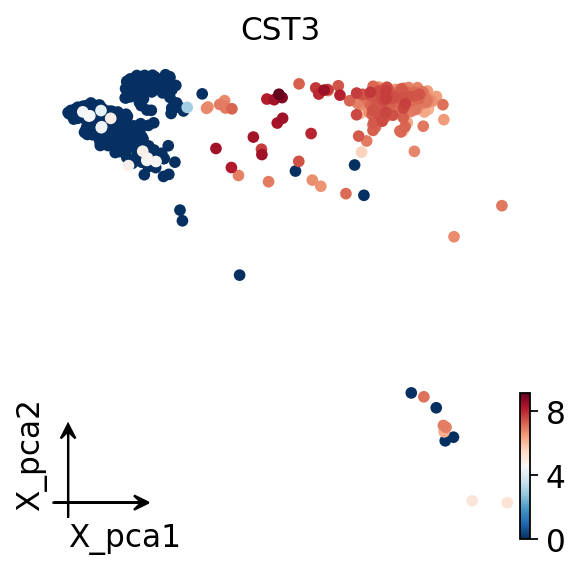

In [14]:
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pl.embedding(adata,
                basis='X_pca',
                color='CST3',
                frameon='small')

## Alternative: the kb-python backend

OmicVerse also ships the kallisto / bustools / **kb-python** workflow as a
second preprocessing backend, exposed through `ov.alignment.single`:

```python
# Build a kallisto index from the same genome + GTF
ref_res = ov.alignment.single.ref(
    fasta_paths='pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz',
    gtf_paths='pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz',
    index_path='pbmc_1k_v3/index.idx',
    t2g_path='pbmc_1k_v3/t2g.txt',
    cdna_path='pbmc_1k_v3/cdna.fa',
)

# Quantify the FASTQs into an h5ad count matrix
count_res = ov.alignment.single.count(
    fastq_paths=reads1 + reads2,          # interleaved R1/R2 file list
    index_path='pbmc_1k_v3/index.idx',
    t2g_path='pbmc_1k_v3/t2g.txt',
    technology='10XV3',
    output_path='pbmc_1k_v3',
    h5ad=True,
    filter_barcodes=True,
)
```

The two backends produce equivalent gene-by-cell matrices; pick whichever fits
your environment. The downstream OmicVerse analysis (QC -> preprocess -> scale
-> PCA -> embedding) is identical regardless of which quantifier you used.

* Sullivan, D.K., Min, K.H.(.), Hjorleifsson, K.E. et al. kallisto, bustools and
  kb-python for quantifying bulk, single-cell and single-nucleus RNA-seq.
  *Nature Protocols* (2025). https://doi.org/10.1038/s41596-024-01057-0